# 06 Results and Interpretation

## Goal

This notebook summarises the results of the climate exposure-screening project.

The previous notebook created a preliminary exposure score and Low / Medium / High screening categories for operational UK renewable energy assets.

This notebook focuses on:

1. headline portfolio metrics,
2. screening category distribution,
3. regional exposure summaries,
4. top-ranked assets for further review,
5. interpretation and limitations.

The purpose is to communicate what the model found and what the results do — and do not — mean.

In [1]:
from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUTS = PROJECT_ROOT / "outputs"
FIGURES = OUTPUTS / "figures"
TABLES = OUTPUTS / "tables"

FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

scored_path = DATA_PROCESSED / "operational_energy_assets_scored.geojson"

assets = gpd.read_file(scored_path)

print("Rows:", len(assets))
print("CRS:", assets.crs)

assets.head()

ModuleNotFoundError: No module named 'geopandas'

## Portfolio headline metrics

The first step is to create headline metrics for the scored asset universe.

These metrics summarise the overall portfolio before looking at regional or asset-level detail.

In [39]:
capacity_col = "Installed Capacity (MWelec)"

headline_metrics = {
    "total_scored_assets": len(assets),
    "total_installed_capacity_mw": assets[capacity_col].sum(),
    "average_installed_capacity_mw": assets[capacity_col].mean(),
    "high_screening_assets": (assets["screening_category"] == "High").sum(),
    "medium_screening_assets": (assets["screening_category"] == "Medium").sum(),
    "low_screening_assets": (assets["screening_category"] == "Low").sum(),
}

headline_metrics

{'total_scored_assets': 3058,
 'total_installed_capacity_mw': np.float64(54862.0),
 'average_installed_capacity_mw': np.float64(18.208430136077),
 'high_screening_assets': np.int64(8),
 'medium_screening_assets': np.int64(1019),
 'low_screening_assets': np.int64(2031)}

In [40]:
headline_metrics_df = pd.DataFrame(
    headline_metrics.items(),
    columns=["metric", "value"]
)

headline_metrics_df

,metric,value
0,total_scored_assets,3058.00000
1,total_installed_capacity_mw,54862.00000
2,average_installed_capacity_mw,18.20843
3,high_screening_assets,8.00000
4,medium_screening_assets,1019.00000
5,low_screening_assets,2031.00000


In [41]:
headline_metrics_df.to_csv(
    TABLES / "headline_metrics.csv",
    index=False
)

print("Saved headline metrics to:", TABLES / "headline_metrics.csv")

Saved headline metrics to: /Users/oconnor/jaurice-market-notes/projects/physical-climate-risk-uk-energy/outputs/tables/headline_metrics.csv


## Screening category distribution

The screening categories show how many operational renewable energy assets fall into Low, Medium and High preliminary exposure categories.

These categories are communication labels only. They are not validated catastrophe risk bands.

In [42]:
category_counts = (
    assets["screening_category"]
    .value_counts()
    .reindex(["Low", "Medium", "High"])
    .fillna(0)
    .astype(int)
)

category_counts

screening_category
Low       2031
Medium    1019
High         8
Name: count, dtype: int64

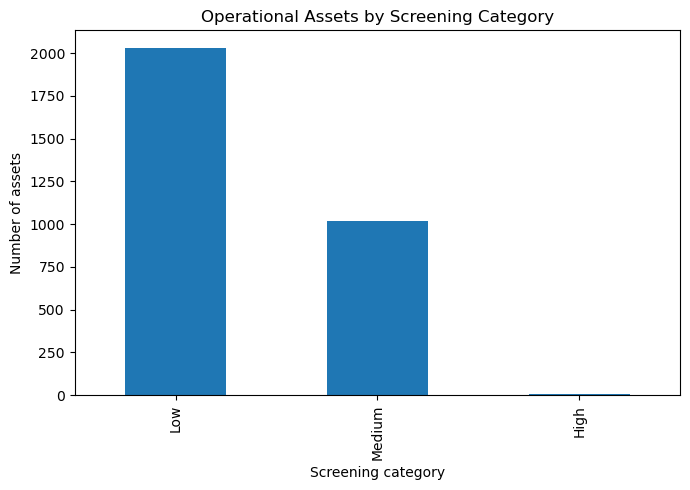

Saved figure to: /Users/oconnor/jaurice-market-notes/projects/physical-climate-risk-uk-energy/outputs/figures/results_screening_category_distribution.png


In [43]:
fig, ax = plt.subplots(figsize=(7, 5))

category_counts.plot(kind="bar", ax=ax)

ax.set_title("Operational Assets by Screening Category")
ax.set_xlabel("Screening category")
ax.set_ylabel("Number of assets")

plt.tight_layout()

figure_path = FIGURES / "results_screening_category_distribution.png"
plt.savefig(figure_path, dpi=200)

plt.show()

print("Saved figure to:", figure_path)

## Regional exposure summary

The regional summary shows how exposure-screening results vary across regions.

This is useful because risk is often interpreted at more than one level:

- individual asset level,
- regional level,
- portfolio level.

A region may have many assets, high total installed capacity, or a concentration of higher-scored assets. These are related but different views of exposure.

In [44]:
regional_summary = (
    assets
    .groupby("Region")
    .agg(
        asset_count=("Ref ID", "count"),
        total_capacity_mw=(capacity_col, "sum"),
        mean_capacity_mw=(capacity_col, "mean"),
        mean_exposure_score=("preliminary_exposure_score", "mean"),
        high_screening_count=("screening_category", lambda x: (x == "High").sum()),
        medium_screening_count=("screening_category", lambda x: (x == "Medium").sum()),
        low_screening_count=("screening_category", lambda x: (x == "Low").sum()),
    )
    .reset_index()
    .sort_values("high_screening_count", ascending=False)
)

regional_summary

,Region,asset_count,total_capacity_mw,mean_capacity_mw,mean_exposure_score,high_screening_count,medium_screening_count,low_screening_count
6,Offshore,53,14713.50,277.613208,2.056604,5,43,5
5,Northern Ireland,118,1453.50,12.317797,1.372881,1,62,55
7,Scotland,565,12382.83,22.311405,1.097345,1,254,310
9,South West,529,3907.90,7.500768,0.922495,1,119,409
0,East Midlands,268,2010.06,7.585132,0.914179,0,73,195
1,Eastern,326,3378.04,10.490807,1.021472,0,120,206
2,London,35,388.62,11.776364,0.657143,0,8,27
3,North East,103,1319.61,12.937353,0.912621,0,28,75
4,North West,194,1572.56,8.147979,0.711340,0,38,156
8,South East,312,3468.95,11.226375,1.009615,0,100,212


In [45]:
regional_summary.to_csv(
    TABLES / "final_regional_exposure_summary.csv",
    index=False
)

print("Saved regional summary to:", TABLES / "final_regional_exposure_summary.csv")

Saved regional summary to: /Users/oconnor/jaurice-market-notes/projects/physical-climate-risk-uk-energy/outputs/tables/final_regional_exposure_summary.csv


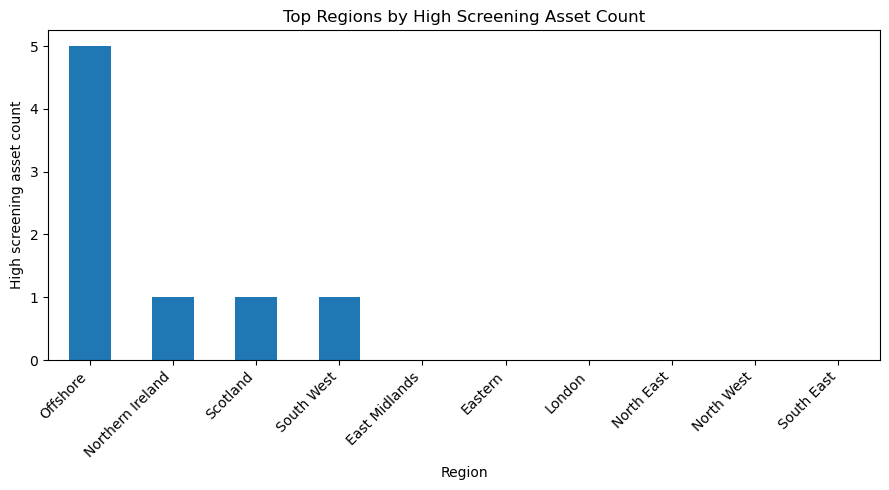

Saved figure to: /Users/oconnor/jaurice-market-notes/projects/physical-climate-risk-uk-energy/outputs/figures/top_regions_high_screening_count.png


In [46]:
top_regions_by_high_count = regional_summary.sort_values(
    "high_screening_count",
    ascending=False
).head(10)

fig, ax = plt.subplots(figsize=(9, 5))

top_regions_by_high_count.plot(
    x="Region",
    y="high_screening_count",
    kind="bar",
    ax=ax,
    legend=False
)

ax.set_title("Top Regions by High Screening Asset Count")
ax.set_xlabel("Region")
ax.set_ylabel("High screening asset count")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

figure_path = FIGURES / "top_regions_high_screening_count.png"
plt.savefig(figure_path, dpi=200)

plt.show()

print("Saved figure to:", figure_path)

## Top-ranked assets for review

The table below lists the highest-scored assets under the Version 1 screening framework.

These assets are not automatically “high risk” in a formal loss-modelling sense. Instead, they are assets that combine higher proximity scores with higher installed-capacity scores under the assumptions used in this prototype.

## Top-ranked assets for review

The table below lists the highest-scored assets under the Version 1 screening framework.

These assets are not automatically “high risk” in a formal loss-modelling sense. Instead, they are assets that combine higher proximity scores with higher installed-capacity scores under the assumptions used in this prototype.

In [47]:
top_assets = (
    assets[[
        "Ref ID",
        "Site Name",
        "Technology Type",
        "Region",
        "Installed Capacity (MWelec)",
        "distance_to_boundary_m",
        "proximity_score",
        "capacity_score",
        "preliminary_exposure_score",
        "screening_category"
    ]]
    .sort_values(
        ["preliminary_exposure_score", "Installed Capacity (MWelec)"],
        ascending=[False, False]
    )
    .head(25)
)

top_assets

,Ref ID,Site Name,Technology Type,Region,Installed Capacity (MWelec),distance_to_boundary_m,proximity_score,capacity_score,preliminary_exposure_score,screening_category
1342,2502,Hornsea 2 - Optimus and Breesea,Wind Offshore,Offshore,1320.0,3896.293647,2,2,4,High
1357,2524,East Anglia 1 (EA 1),Wind Offshore,Offshore,714.0,0.000000,2,2,4,High
1354,2520,Rampion Offshore Wind Farm (Hastings Zone),Wind Offshore,Offshore,400.0,0.000000,2,2,4,High
1359,2526,Galloper Wind Farm,Wind Offshore,Offshore,353.0,0.000000,2,2,4,High
1340,2499,Thanet,Wind Offshore,Offshore,300.0,0.000000,2,2,4,High
2087,4673,Callagheen,Wind Onshore,Northern Ireland,22.8,0.000000,2,2,4,High
1842,4063,Pentland Road Wind Farm,Wind Onshore,Scotland,13.8,4353.640811,2,2,4,High
1464,3061,Goonhilly Downs Wind Farm Repower,Wind Onshore,South West,12.0,442.458716,2,2,4,High
1347,2510,Greater Gabbard Wind Farm,Wind Offshore,Offshore,504.0,8583.655389,1,2,3,Medium
1473,3096,Little Cheyne Court Wind Farm,Wind Onshore,South East,59.8,5310.587335,1,2,3,Medium


In [48]:
top_assets.to_csv(
    TABLES / "top_25_assets_for_review.csv",
    index=False
)

print("Saved top assets table to:", TABLES / "top_25_assets_for_review.csv")

Saved top assets table to: /Users/oconnor/jaurice-market-notes/projects/physical-climate-risk-uk-energy/outputs/tables/top_25_assets_for_review.csv


## Key findings

The Version 1 screening model produces several useful outputs:

1. A cleaned portfolio of operational renewable energy assets with valid coordinates.
2. A reusable spatial asset layer.
3. A first-pass geographic exposure proxy.
4. A preliminary exposure score combining proximity and installed capacity.
5. Regional and asset-level summaries for further review.

The main value of the project is not that it produces a final climate-risk answer. The value is that it demonstrates a transparent workflow for turning public asset data into a structured exposure-screening view.

## Interpretation

The screening score should be interpreted as a prioritisation tool.

A higher score means that an asset combines:

- closer proximity to the boundary proxy, and/or
- higher installed capacity.

This may indicate that the asset deserves closer review in a more detailed physical climate risk assessment.

However, the score does not estimate:

- probability of flooding,
- heat-stress intensity,
- asset failure probability,
- financial loss,
- insured loss,
- replacement cost,
- engineering vulnerability.

For this reason, the output should be described as a preliminary exposure screen rather than a full catastrophe or physical climate risk model.

## Limitations

This Version 1 project has several important limitations:

| Limitation | Why it matters |
|---|---|
| Boundary proxy is not a formal hazard layer | It cannot be interpreted as true flood, heat or coastal risk |
| Installed capacity is not asset value | It does not measure insured value, replacement cost or revenue exposure |
| Only renewable energy assets are included | Transport and wider infrastructure assets are not yet included |
| No vulnerability functions are used | The model does not estimate damage or failure probability |
| No climate scenarios are included | The model is not yet forward-looking under different warming pathways |

These limitations are important because they define what can and cannot be claimed from the model.

## Limitations

This Version 1 project has several important limitations:

| Limitation | Why it matters |
|---|---|
| Boundary proxy is not a formal hazard layer | It cannot be interpreted as true flood, heat or coastal risk |
| Installed capacity is not asset value | It does not measure insured value, replacement cost or revenue exposure |
| Only renewable energy assets are included | Transport and wider infrastructure assets are not yet included |
| No vulnerability functions are used | The model does not estimate damage or failure probability |
| No climate scenarios are included | The model is not yet forward-looking under different warming pathways |

These limitations are important because they define what can and cannot be claimed from the model.

In [49]:
print("Final project outputs created:")
print("- headline_metrics.csv")
print("- final_regional_exposure_summary.csv")
print("- top_25_assets_for_review.csv")
print("- results_screening_category_distribution.png")
print("- top_regions_high_screening_count.png")

Final project outputs created:
- headline_metrics.csv
- final_regional_exposure_summary.csv
- top_25_assets_for_review.csv
- results_screening_category_distribution.png
- top_regions_high_screening_count.png
